# Import relevant libraries

In [1]:
#!pip install matplotlib pandas scikit-learn
#!pip install --upgrade pip
#!pip install statsmodels

In [2]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from math import sin, cos, sqrt, atan2, radians
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (auc, classification_report, roc_auc_score, accuracy_score,
                             f1_score, log_loss, roc_curve, confusion_matrix, precision_score, recall_score)
import statsmodels.formula.api as smf

np.random.seed(0)

#Load the Data 

In [3]:
tournament_Data = pd.read_csv('https://raw.githubusercontent.com/SethiDeepika/AIML/main/NCAA_Tourney_2002_2025.csv')
tournament_Data.head()
#tournament_TestData = pd.read_csv('https://raw.githubusercontent.com/SethiDeepika/AIML/main/NCAA_Tourney_2002_2025.csv').query("season==2019").reset_index(drop=True)
#tournament_TestData.head()

,team1_id,team1_score,team2_id,team2_score,WLoc,num_ot,team1_position,team2_position,team1_seed,team2_seed,...,team1_adjoe,team1_de,team1_adjde,team2_tempo,team2_adjtempo,team2_oe,team2_adjoe,team2_de,team2_adjde,game_id
0,1314,81.0,1181,77.0,N,0.0,W08,X02,8,2,...,113.035,100.974,96.9911,68.2765,67.4185,117.1520,119.3570,98.2346,95.6444,2022-1314-1181
1,1242,81.0,1437,65.0,N,0.0,Y01,Z02,1,2,...,119.388,97.191,93.9009,64.1915,62.5758,112.8450,117.9210,97.6798,93.8099,2022-1242-1437
2,1242,72.0,1314,69.0,N,0.0,Y01,W08,1,8,...,119.388,97.191,93.9009,70.2181,70.1745,109.4160,113.0350,100.9740,96.9911,2022-1242-1314
3,1242,76.0,1274,50.0,N,0.0,Y01,Y10,1,10,...,119.388,97.191,93.9009,67.5221,67.3101,110.3680,114.7570,104.9830,102.1320,2022-1242-1274
4,1314,69.0,1389,49.0,N,0.0,W08,W15,8,15,...,113.035,100.974,96.9911,67.0262,65.9923,98.7557,98.7475,92.3289,94.4745,2022-1314-1389


In [4]:
# The data has team1 as the winner. We need to create balanced training data
# by also including the reverse matchups (team2 vs team1)
print("\nPreparing training data...")



Preparing training data...


In [5]:
df_winner = tournament_Data.copy()
df_winner['target'] = 1  # team1 wins
df_loser = tournament_Data.copy()
df_loser['target'] = 0  # team2 loses

team1_cols = [c for c in tournament_Data.columns if c.startswith('team1_')]
team2_cols = [c for c in tournament_Data.columns if c.startswith('team2_')]


# Put Team 2 data into Team 1's columns
df_loser[team1_cols] = tournament_Data[team2_cols].values

# Put Team 1 data into Team 2's columns
df_loser[team2_cols] = tournament_Data[team1_cols].values

# Feature engineering
stat_cols_team1 = [
    'team1_fg2pct', 'team1_fg3pct', 'team1_ftpct', 'team1_blockpct',
    'team1_oppfg2pct', 'team1_oppfg3pct', 'team1_arate', 'team1_opparate',
    'team1_stlrate', 'team1_oppstlrate', 'team1_adjoe', 'team1_adjde'
]

stat_cols_team2 = [
    'team2_fg2pct', 'team2_fg3pct', 'team2_ftpct', 'team2_blockpct',
    'team2_oppfg2pct', 'team2_oppfg3pct', 'team2_arate', 'team2_opparate',
    'team2_stlrate', 'team2_oppstlrate', 'team2_adjoe', 'team2_adjde'
]

df_combined = pd.concat([df_winner, df_loser], axis=0).reset_index(drop=True)
df_combined = df_combined.sort_values(by=['game_id']).reset_index(drop=True)
feature_names = []

for t1, t2 in zip(stat_cols_team1, stat_cols_team2):
    base_name = t1.replace('team1_', '')
    df_combined[f'diff_{base_name}'] = df_combined[t1] - df_combined[t2]
    feature_names.append(f'diff_{base_name}')

# Seed difference
df_combined['seed_diff'] = df_combined['team2_seed'] - df_combined['team1_seed']
feature_names.append('seed_diff')

# Net efficiency difference
df_combined['team1_net_eff'] = df_combined['team1_adjoe'] - df_combined['team1_adjde']
df_combined['team2_net_eff'] = df_combined['team2_adjoe'] - df_combined['team2_adjde']
df_combined['diff_net_eff'] = df_combined['team1_net_eff'] - df_combined['team2_net_eff']
feature_names.append('diff_net_eff')



# Is team offense-heavy or defense-heavy?
df_combined['team1_off_def_ratio'] = df_combined['team1_adjoe'] / df_combined['team1_adjde']
df_combined['team2_off_def_ratio'] = df_combined['team2_adjoe'] / df_combined['team2_adjde']
df_combined['diff_off_def_ratio'] = df_combined['team1_off_def_ratio'] - df_combined['team2_off_def_ratio']

feature_names.append('diff_off_def_ratio')

In [6]:
#Feature Engineering Using Claude

# ===== 1. TEMPO FEATURES =====
df_combined['diff_tempo'] = df_combined['team1_tempo'] - df_combined['team2_tempo']
df_combined['diff_adjtempo'] = df_combined['team1_adjtempo'] - df_combined['team2_adjtempo']
feature_names.extend(['diff_tempo', 'diff_adjtempo'])

# ===== 2. UPSET INDICATORS =====
df_combined['upset_potential'] = ((df_combined['seed_diff'] < 0) & (df_combined['diff_net_eff'] > 0)).astype(int)
df_combined['seed_diff_sq'] = df_combined['seed_diff'] ** 2
feature_names.extend(['upset_potential', 'seed_diff_sq'])

# ===== 3. SHOOTING EFFICIENCY =====
df_combined['team1_overall_fg'] = df_combined['team1_fg2pct'] * 0.6 + df_combined['team1_fg3pct'] * 0.4
df_combined['team2_overall_fg'] = df_combined['team2_fg2pct'] * 0.6 + df_combined['team2_fg3pct'] * 0.4
df_combined['diff_overall_fg'] = df_combined['team1_overall_fg'] - df_combined['team2_overall_fg']
feature_names.append('diff_overall_fg')

# ===== 4. DEFENSIVE PRESSURE =====
df_combined['team1_def_pressure'] = df_combined['team1_stlrate'] + df_combined['team1_blockpct']
df_combined['team2_def_pressure'] = df_combined['team2_stlrate'] + df_combined['team2_blockpct']
df_combined['diff_def_pressure'] = df_combined['team1_def_pressure'] - df_combined['team2_def_pressure']
feature_names.append('diff_def_pressure')

# ===== 5. TURNOVER MARGIN =====
df_combined['team1_to_margin'] = df_combined['team1_stlrate'] - df_combined['team1_oppstlrate']
df_combined['team2_to_margin'] = df_combined['team2_stlrate'] - df_combined['team2_oppstlrate']
df_combined['diff_to_margin'] = df_combined['team1_to_margin'] - df_combined['team2_to_margin']
feature_names.append('diff_to_margin')

# ===== 6. LUCK (EFF VS SEED) =====
seed_to_eff = {1:28, 2:24, 3:21, 4:18, 5:16, 6:14, 7:12, 8:10, 9:8, 10:6, 11:5, 12:4, 13:2, 14:0, 15:-2, 16:-5}
df_combined['team1_eff_vs_seed'] = df_combined['team1_net_eff'] - df_combined['team1_seed'].map(seed_to_eff)
df_combined['team2_eff_vs_seed'] = df_combined['team2_net_eff'] - df_combined['team2_seed'].map(seed_to_eff)
df_combined['diff_eff_vs_seed'] = df_combined['team1_eff_vs_seed'] - df_combined['team2_eff_vs_seed']
feature_names.append('diff_eff_vs_seed')

# ===== 7. MATCHUP ADVANTAGE =====
df_combined['matchup_advantage'] = (df_combined['team1_adjoe'] - df_combined['team2_adjde']) - (df_combined['team2_adjoe'] - df_combined['team1_adjde'])
feature_names.append('matchup_advantage')

# ===== 8. TEMPO MISMATCH =====
df_combined['tempo_mismatch'] = abs(df_combined['team1_tempo'] - df_combined['team2_tempo'])
feature_names.append('tempo_mismatch')

df_combined

,team1_id,team1_score,team2_id,team2_score,WLoc,num_ot,team1_position,team2_position,team1_seed,team2_seed,...,team2_def_pressure,diff_def_pressure,team1_to_margin,team2_to_margin,diff_to_margin,team1_eff_vs_seed,team2_eff_vs_seed,diff_eff_vs_seed,matchup_advantage,tempo_mismatch
0,1194,78.0,1104,86.0,N,0.0,Y15,Y02,15,2,...,8.1521,0.1632,0.0206,0.0172,0.0034,-1.0594,-6.3816,5.3222,-8.5792,1.3721
1,1104,86.0,1194,78.0,N,0.0,Y02,Y15,2,15,...,8.3153,-0.1632,0.0172,0.0206,-0.0034,-6.3816,-1.0594,-5.3222,8.5792,1.3721
2,1112,86.0,1364,81.0,N,0.0,Z03,Z14,3,14,...,8.8053,-1.4706,-0.0004,0.009,-0.0094,-0.5385,7.783,-8.3215,11.1901,10.9117
3,1364,81.0,1112,86.0,N,0.0,Z14,Z03,14,3,...,7.3347,1.4706,0.009,-0.0004,0.0094,7.783,-0.5385,8.3215,-11.1901,10.9117
4,1112,68.0,1461,60.0,N,0.0,Z03,Z11,3,11,...,10.5315,-3.1968,-0.0004,-0.0108,0.0104,-0.5385,4.3769,-4.9154,11.6168,4.529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3023,1417,72.0,1429,47.0,N,0.0,X07,X10,7,10,...,9.516012,1.108869,0.03662,0.025999,0.010622,9.7623,9.225,0.5373,-14.3073,0.7496
3024,1285,66.0,1458,85.0,N,0.0,W14,W03,14,3,...,6.180186,1.98756,0.007142,0.006637,0.000505,0.384,4.9749,-4.5909,3.1149,1.1587
3025,1458,85.0,1285,66.0,N,0.0,W03,W14,3,14,...,8.167746,-1.98756,0.006637,0.007142,-0.000505,4.9749,0.384,4.5909,-3.1149,1.1587
3026,1400,80.0,1462,86.0,N,0.0,X11a,X11b,11,11,...,7.264909,4.562444,0.007624,0.025461,-0.017837,12.1514,12.197,-0.0456,2.4736,1.0204


In [7]:
def distance(lat1, lon1, lat2, lon2):

    # approximate radius of earth in km
    R = 6373.0

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    
    return distance

df_combined['dist1'] = df_combined.apply(lambda row: distance(row['host_lat'], row['host_long'], row['team1_lat'], row['team1_long']), axis=1)
df_combined['dist2'] = df_combined.apply(lambda row: distance(row['host_lat'], row['host_long'], row['team2_lat'], row['team2_long']), axis=1)

df_combined['diff_dist'] = df_combined['dist1'] - df_combined['dist2']

feature_names.append('diff_dist')

In [8]:


df_training = pd.concat([df_winner, df_loser], axis=0).reset_index(drop=True)
df_training = df_training.sort_values(by=['game_id']).reset_index(drop=True)

#df_training=df_combined[feature_names]
df_training.head()

,team1_id,team1_score,team2_id,team2_score,WLoc,num_ot,team1_position,team2_position,team1_seed,team2_seed,...,team1_de,team1_adjde,team2_tempo,team2_adjtempo,team2_oe,team2_adjoe,team2_de,team2_adjde,game_id,target
0,1194,78.0,1104,86.0,N,0.0,Y15,Y02,15,2,...,98.4183,99.9263,69.8636,69.9001,108.4361,111.4954,95.2313,93.877,2002-1104-1194,0
1,1104,86.0,1194,78.0,N,0.0,Y02,Y15,2,15,...,95.2313,93.877,71.2357,71.2446,100.2897,96.8669,98.4183,99.9263,2002-1104-1194,1
2,1112,86.0,1364,81.0,N,0.0,Z03,Z14,3,14,...,104.0411,96.9262,63.2345,64.7948,105.2163,105.4534,96.0965,97.6704,2002-1112-1364,1
3,1364,81.0,1112,86.0,N,0.0,Z14,Z03,14,3,...,96.0965,97.6704,74.1462,72.8207,111.0077,117.3877,104.0411,96.9262,2002-1112-1364,0
4,1112,68.0,1461,60.0,N,0.0,Z03,Z11,3,11,...,104.0411,96.9262,69.6172,70.4124,105.3654,106.037,97.0568,96.6601,2002-1112-1461,1


In [9]:
df_training.shape

(3028, 67)

In [10]:
#!pip install tensorflow

In [11]:
# Keras imports
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Sklearn for preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

2026-02-15 08:40:49.829029: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [12]:
df_combined
#df_combined[df_combined['season'] != '2019']
df_combined[df_combined['season'] != 2019]

,team1_id,team1_score,team2_id,team2_score,WLoc,num_ot,team1_position,team2_position,team1_seed,team2_seed,...,team2_to_margin,diff_to_margin,team1_eff_vs_seed,team2_eff_vs_seed,diff_eff_vs_seed,matchup_advantage,tempo_mismatch,dist1,dist2,diff_dist
0,1194,78.0,1104,86.0,N,0.0,Y15,Y02,15,2,...,0.0172,0.0034,-1.0594,-6.3816,5.3222,-8.5792,1.3721,1058.900224,970.079692,88.820532
1,1104,86.0,1194,78.0,N,0.0,Y02,Y15,2,15,...,0.0206,-0.0034,-6.3816,-1.0594,-5.3222,8.5792,1.3721,970.079692,1058.900224,-88.820532
2,1112,86.0,1364,81.0,N,0.0,Z03,Z14,3,14,...,0.009,-0.0094,-0.5385,7.783,-8.3215,11.1901,10.9117,513.690472,1211.232761,-697.542289
3,1364,81.0,1112,86.0,N,0.0,Z14,Z03,14,3,...,-0.0004,0.0094,7.783,-0.5385,8.3215,-11.1901,10.9117,1211.232761,513.690472,697.542289
4,1112,68.0,1461,60.0,N,0.0,Z03,Z11,3,11,...,-0.0108,0.0104,-0.5385,4.3769,-4.9154,11.6168,4.529,513.690472,695.686278,-181.995806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3023,1417,72.0,1429,47.0,N,0.0,X07,X10,7,10,...,0.025999,0.010622,9.7623,9.225,0.5373,-14.3073,0.7496,3067.480499,2357.649930,709.830569
3024,1285,66.0,1458,85.0,N,0.0,W14,W03,14,3,...,0.006637,0.000505,0.384,4.9749,-4.5909,3.1149,1.1587,1074.442336,1349.784940,-275.342604
3025,1458,85.0,1285,66.0,N,0.0,W03,W14,3,14,...,0.007142,-0.000505,4.9749,0.384,4.5909,-3.1149,1.1587,1349.784940,1074.442336,275.342604
3026,1400,80.0,1462,86.0,N,0.0,X11a,X11b,11,11,...,0.025461,-0.017837,12.1514,12.197,-0.0456,2.4736,1.0204,1619.291385,72.169178,1547.122207


In [13]:
df_combined_Train = df_combined[df_combined['season'] != 2019]

num_cols = df_combined_Train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_combined_Train.select_dtypes(include=['object']).columns

df_combined_Train[num_cols] = df_combined_Train[num_cols].fillna(
    df_combined_Train[num_cols].median())

for col in cat_cols:
    df_combined_Train[col] = df_combined_Train[col].fillna(
        df_combined_Train[col].mode()[0])

# Features (X) and Target (y)
X = df_combined_Train[feature_names].values
y = df_combined_Train['target'].values
#print(feature_names)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (2894, 26)
y shape: (2894,)


/tmp/ipykernel_740/2104169427.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_combined_Train.select_dtypes(include=['object']).columns


In [14]:
scaler = StandardScaler()
import numpy as np

X_train_scaled = scaler.fit_transform(X)



In [15]:
from tensorflow.keras import regularizers
model = Sequential()

# Input layer + First hidden layer
# input_dim = number of features
model.add(Dense(64, activation='relu',
#kernel_regularizer=regularizers.l2(0.002), 
input_dim=X_train_scaled.shape[1]))
model.add(Dropout(0.3))  # Dropout to prevent overfitting

# Second hidden layer
model.add(Dense(64,
# kernel_regularizer=regularizers.l2(0.002),
activation='relu'))
model.add(Dropout(0.3))

# Third hidden layer
#model.add(Dense(128, kernel_regularizer=regularizers.l2(0.002),activation='relu'))
#model.add(Dense(64, kernel_regularizer=regularizers.l2(0.002),activation='relu'))
model.add(Dense(64, activation='relu'))

#model.add(Dense(64, activation='relu'))

# Output layer (1 neuron with sigmoid for binary classification)
model.add(Dense(1, activation='sigmoid'))
#model.add(Dense(2, activation='softmax'))

print("✅ Model built!")
model.summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-15 08:41:04.515581: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✅ Model built!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer=
    "rmsprop",
    #Adam(learning_rate=0.00001),  # Adam optimizer with default learning rate
    loss='binary_crossentropy',
    #loss = 'sparse_categorical_crossentropy' ,          # Loss function for binary classification
    metrics=['accuracy']                   # Track accuracy during training
)

print("✅ Model compiled!")

✅ Model compiled!


In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',      # Watch validation loss
    patience=10,             # Wait 10 epochs before stopping
    restore_best_weights=True  # Keep the best model
)

print("✅ Early stopping configured")

✅ Early stopping configured


In [18]:

print("🏋️ Training the model...\n")


history = model.fit(
    X_train_scaled, 
    y,
    epochs=100,              # Maximum epochs (early stopping will likely stop before)
    batch_size=32,           # Process 32 samples at a time
    validation_split=0.2,    # Use 20% of training data for validation
    callbacks=[early_stop],  # Use early stopping
    verbose=1                # Show progress
)


print(f"\n✅ Training complete! Stopped at epoch {len(history.history['loss'])}")
print(history.history)

🏋️ Training the model...

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6756 - loss: 0.5986 - val_accuracy: 0.6701 - val_loss: 0.6066
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7024 - loss: 0.5632 - val_accuracy: 0.6667 - val_loss: 0.6117
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7058 - loss: 0.5597 - val_accuracy: 0.6788 - val_loss: 0.6072
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7050 - loss: 0.5583 - val_accuracy: 0.6753 - val_loss: 0.5996
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7197 - loss: 0.5466 - val_accuracy: 0.6684 - val_loss: 0.6116
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7097 - loss: 0.5428 - val_accuracy: 0.6684 - val_loss: 0.6093
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7080 - loss: 0.5423 - val_accuracy: 0.6736 - val_loss: 0.6130
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7192 - loss: 0.5409 

In [19]:

df_combined_Test = df_combined[df_combined['season'] == 2019]


# Features (X) and Target (y)
X_test = df_combined_Test[feature_names].values
X_test_scaled = scaler.transform(X_test)
y_test = df_combined_Test['target'].values


test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print("="*50)
print("📊 TEST SET RESULTS")
print("="*50)
print(f"Test Accuracy: {test_accuracy:.2%}")
print(f"Test Loss: {test_loss:.4f}")

#y_test

📊 TEST SET RESULTS
Test Accuracy: 76.87%
Test Loss: 0.4633


In [20]:
y_pred_proba = model.predict(X_test_scaled)  # Probabilities#
#y_pred_proba = y_pred_proba[:, 1] 

# 3. Apply your custom 0.6 threshold
y_pred = (y_pred_proba > 0.5).astype(int)

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Team2 Wins', 'Team1 Wins']))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

📋 Classification Report:
              precision    recall  f1-score   support

  Team2 Wins       0.76      0.79      0.77        67
  Team1 Wins       0.78      0.75      0.76        67

    accuracy                           0.77       134
   macro avg       0.77      0.77      0.77       134
weighted avg       0.77      0.77      0.77       134



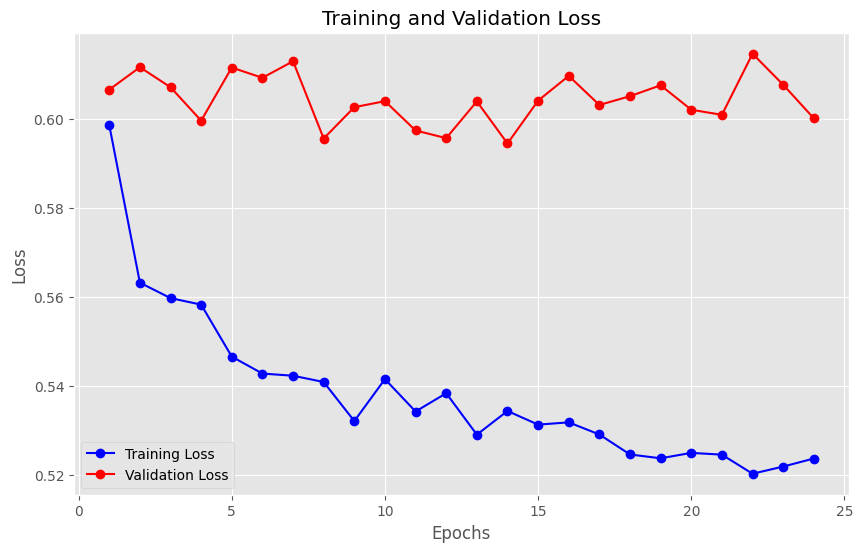

In [21]:
import matplotlib.pyplot as plt

def plot_loss(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    # This ensures the X-axis always matches the number of completed epochs
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(10, 6))
    
    # Use 'epochs' for the X-axis
    plt.plot(epochs, loss, 'bo-', label='Training Loss') 
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss(history)

In [22]:
#y_pred_proba
from sklearn.metrics import log_loss

# Calculate log loss
logloss = log_loss(y_test, y_pred_proba)
auc=roc_auc_score(y_test, y_pred_proba)

print(f"Log Loss: {logloss:.4f}")
print(f"auc: {auc:.4f}")

Log Loss: 0.4633
auc: 0.8648


#Better Logloss if claude features are not included 


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


                      accuracy       auc   logloss
LogisticRegression    0.716418  0.858098  0.453260
SVM_RBF               0.768657  0.855202  0.497191
ExtraTrees            0.701493  0.839608  0.484700
KNN                   0.723881  0.836712  0.486849
RandomForest          0.694030  0.826242  0.496854
XGBoost               0.701493  0.824683  0.500170
HistGradientBoosting  0.686567  0.805302  0.578016


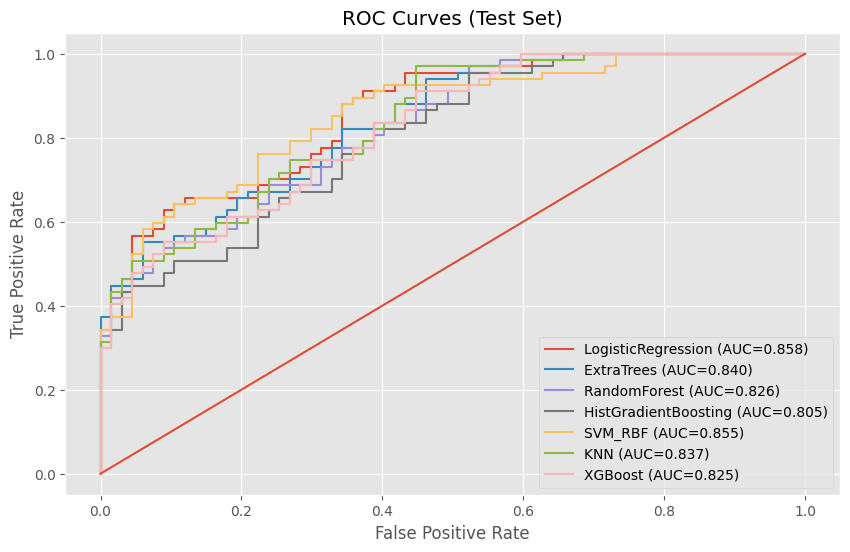

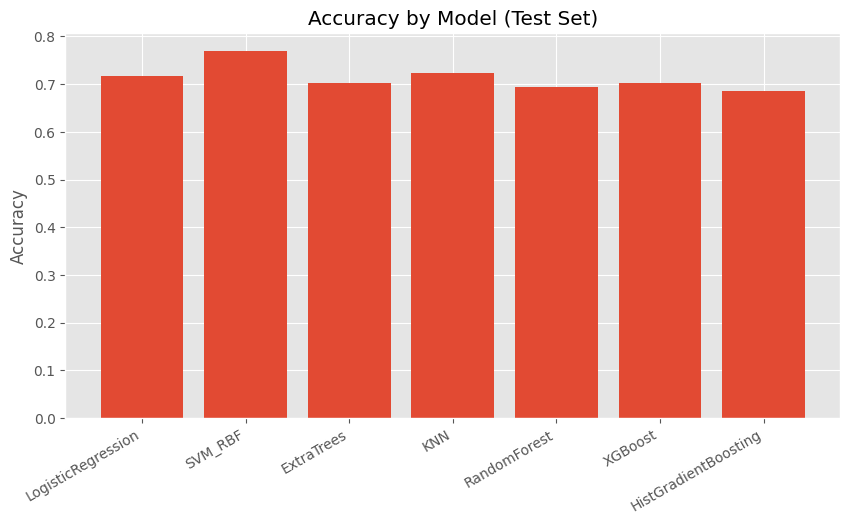

In [23]:
#Other Models
#!pip install xgboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.impute import SimpleImputer

# Create an imputer (fills NaNs with the mean of the column)
imputer = SimpleImputer(strategy='mean') 

# Apply to your features (assuming X_train_scaled/X_test_scaled came from X_train/X_test)
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

# Update your sparse/dense assignments
Xtr_sparse = X_train_imputed
Xte_sparse = X_test_imputed

def to_dense_if_sparse(M):
    return M.toarray() if hasattr(M, "toarray") else M


Xtr_dense  = to_dense_if_sparse(Xtr_sparse)
Xte_dense  = to_dense_if_sparse(Xte_sparse)

try:
    from xgboost import XGBClassifier
    xgb_ok = True
except Exception as e:
    xgb_ok = False
    print("XGBoost not available. Install with: pip install xgboost")
    print("Import error:", e)

models = {
    "LogisticRegression": LogisticRegression(max_iter=8000, n_jobs=-1),
    

    "ExtraTrees": ExtraTreesClassifier(n_estimators=1200, random_state=42, n_jobs=-1, min_samples_leaf=2),
    "RandomForest": RandomForestClassifier(n_estimators=800, random_state=42, n_jobs=-1, min_samples_leaf=2),

    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42, max_depth=6, learning_rate=0.06, max_iter=400),

    "SVM_RBF": SVC(probability=True, kernel="rbf", C=2.0, gamma="scale", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=35, weights="distance"),
}

if xgb_ok:
    models["XGBoost"] = XGBClassifier(
        n_estimators=900,
        max_depth=5,
        learning_rate=0.01,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )

dense_only = {"HistGradientBoosting", "SVM_RBF", "KNN"}

results = {}
roc_lines = {}

for name, model in models.items():
    Xtr = Xtr_dense if name in dense_only else Xtr_sparse
    Xte = Xte_dense if name in dense_only else Xte_sparse

    model.fit(Xtr, y)

    proba = model.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    ll  = log_loss(y_test, proba)

    results[name] = {"accuracy": acc, "auc": auc, "logloss": ll}

    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_lines[name] = (fpr, tpr)

metrics_df = pd.DataFrame(results).T.sort_values("auc", ascending=False)
print(metrics_df)


plt.figure(figsize=(10, 6))
for name, (fpr, tpr) in roc_lines.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['auc']:.3f})")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))
plt.bar(metrics_df.index, metrics_df["accuracy"].values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.title("Accuracy by Model (Test Set)")
plt.show()


In [24]:
from sklearn.linear_model import LogisticRegression

# Lasso = LogisticRegression with L1 penalty
lasso_model = LogisticRegression(penalty='l1', solver='saga', C=25, max_iter=1000)
lasso_model.fit(X_train_scaled, y)

# Predict
y_pred_lasso = lasso_model.predict(X_test_scaled)
y_pred_proba_lasso = lasso_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
logloss_lasso = log_loss(y_test, y_pred_proba_lasso)

print(f"Lasso Accuracy: {accuracy_lasso:.2%}")
print(f"Lasso Log Loss: {logloss_lasso:.4f}")

# See which features were kept (non-zero coefficients)
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lasso_model.coef_[0]
})
feature_importance['abs_coef'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coef', ascending=False)

print("\n📊 Feature Importance (Lasso):")
print(feature_importance.to_string(index=False))

# Features removed by Lasso (coefficient = 0)
removed = feature_importance[feature_importance['coefficient'] == 0]['feature'].tolist()
print(f"\n❌ Features removed by Lasso: {removed}")

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Lasso Accuracy: 71.64%
Lasso Log Loss: 0.4562

📊 Feature Importance (Lasso):
           feature  coefficient  abs_coef
        diff_adjoe     1.864952  1.864952
        diff_adjde    -1.666602  1.666602
diff_off_def_ratio    -1.604335  1.604335
      diff_net_eff     0.348500  0.348500
  diff_eff_vs_seed    -0.268101  0.268101
         seed_diff    -0.223483  0.223483
     diff_blockpct     0.213797  0.213797
    diff_oppfg2pct     0.171506  0.171506
        diff_arate    -0.141549  0.141549
        diff_tempo    -0.083574  0.083574
        diff_ftpct     0.082681  0.082681
      diff_stlrate     0.075593  0.075593
   diff_oppstlrate    -0.050675  0.050675
         diff_dist    -0.043166  0.043166
     diff_opparate    -0.041328  0.041328
    diff_oppfg3pct    -0.033543  0.033543
       diff_fg3pct     0.033217  0.033217
     diff_adjtempo     0.012108  0.012108
   upset_potential     0.010974  0.010974
   diff_overall_fg     0.003904  0.003904
    diff_to_margin     0.002851  0.002851

In [25]:
# ElasticNet = mix of Ridge and Lasso
elastic_model = LogisticRegression(penalty='elasticnet', solver='saga', 
                                    l1_ratio=0.5, C=1, max_iter=2000)
elastic_model.fit(X_train_scaled, y)

# Predict
y_pred_elastic = elastic_model.predict(X_test_scaled)
y_pred_proba_elastic = elastic_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy_elastic = accuracy_score(y_test, y_pred_elastic)
logloss_elastic = log_loss(y_test, y_pred_proba_elastic)

print(f"ElasticNet Accuracy: {accuracy_elastic:.2%}")
print(f"ElasticNet Log Loss: {logloss_elastic:.4f}")

ElasticNet Accuracy: 71.64%
ElasticNet Log Loss: 0.4531


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [26]:
from sklearn.model_selection import GridSearchCV

# Try different C values
param_grid = {'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

lasso_model = LogisticRegression(penalty='l1', solver='saga', max_iter=2000)

grid_search = GridSearchCV(
    lasso_model, 
    param_grid, 
    cv=5,                  # 5-fold cross validation
    scoring='neg_log_loss', # Optimize for log loss
    verbose=1
)

grid_search.fit(X_train_scaled, y)

print(f"Best C: {grid_search.best_params_['C']}")
print(f"Best Log Loss: {-grid_search.best_score_:.4f}")

# Use best model
best_lasso = grid_search.best_estimator_

Fitting 5 folds for each of 7 candidates, totalling 35 fits


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf in

Best C: 0.1
Best Log Loss: 0.5584


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [27]:
import numpy as np

# Reshape from (rows, cols) to (rows, 1, cols)
X_train_rnn = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_rnn = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print(f"New Shape: {X_train_rnn.shape}")

New Shape: (2894, 1, 26)


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_lstm = Sequential()

# First Layer: LSTM (Must specify input_shape for 3D data)
# input_shape=(time_steps, features)
model_lstm.add(LSTM(128, activation='relu', 
                    input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2]), 
                    return_sequences=True)) 
model_lstm.add(Dropout(0.3))

# Second Layer: Another LSTM
model_lstm.add(LSTM(128, activation='relu', return_sequences=False))
model_lstm.add(Dropout(0.3))

# Third Layer: Standard Dense (Transitioning to output)
model_lstm.add(Dense(128, activation='relu'))
model_lstm.add(Dense(128, activation='relu'))

# Output Layer
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("✅ LSTM Model built!")
model_lstm.summary()

✅ LSTM Model built!


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        79,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,097 (953.50 KB)

 Trainable params: 244,097 (953.50 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
from tensorflow.keras.layers import SimpleRNN

model_rnn = Sequential()

# First Layer: SimpleRNN
model_rnn.add(SimpleRNN(256, activation='tanh', 
                        input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2]), 
                        return_sequences=True))
model_rnn.add(Dropout(0.3))

# Second Layer: SimpleRNN
model_rnn.add(SimpleRNN(128, activation='tanh'))

# Output
model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
print("✅ SimpleRNN Model built!")

✅ SimpleRNN Model built!


In [30]:
# 1. Get the raw probabilities (values between 0 and 1)
# Ensure you use X_test_rnn (the 3D reshaped data)
y_proba = model_lstm.predict(X_test_rnn).flatten()

# 2. Convert probabilities to binary predictions (Threshold = 0.5)
y_pred = (y_proba >= 0.5).astype(int)

print("✅ Predictions generated!")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
✅ Predictions generated!


In [31]:
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score

# Log Loss (Uses probabilities)
# y_test is your ground truth, y_proba is the predicted probability
current_log_loss = log_loss(y_test, y_proba)

# Accuracy (Uses binary classes)
current_accuracy = accuracy_score(y_test, y_pred)

# ROC AUC (Uses probabilities)
current_auc = roc_auc_score(y_test, y_proba)

print(f"--- LSTM Model Results ---")
print(f"Log Loss: {current_log_loss:.4f}")
print(f"Accuracy: {current_accuracy:.4f}")
print(f"ROC AUC:  {current_auc:.4f}")

--- LSTM Model Results ---
Log Loss: 0.6937
Accuracy: 0.3731
ROC AUC:  0.3005


In [32]:
# Assuming 'results' is your dictionary from the previous code block
results["LSTM_Keras"] = {
    "accuracy": current_accuracy, 
    "auc": current_auc, 
    "logloss": current_log_loss
}

# Re-run your sorting and plotting
metrics_df = pd.DataFrame(results).T.sort_values("auc", ascending=False)
print(metrics_df)

                      accuracy       auc   logloss
LogisticRegression    0.716418  0.858098  0.453260
SVM_RBF               0.768657  0.855202  0.497191
ExtraTrees            0.701493  0.839608  0.484700
KNN                   0.723881  0.836712  0.486849
RandomForest          0.694030  0.826242  0.496854
XGBoost               0.701493  0.824683  0.500170
HistGradientBoosting  0.686567  0.805302  0.578016
LSTM_Keras            0.373134  0.300512  0.693716


In [33]:
model_rnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 1, 256)         │        72,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,857 (476.00 KB)

 Trainable params: 121,857 (476.00 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
y_pred_proba2=model_rnn.predict(X_test_rnn)
y_pred2 = (y_pred_proba2 > 0.5).astype(int)

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred2, target_names=['Team2 Wins', 'Team1 Wins']))

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7e569965f740> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

📋 Classification Report:
              precision    recall  f1-score   support

  Team2 Wins       0.32      0.34      0.33        67
  Team1 Wins       0.29      0.27      0.28        67

    accurac

In [35]:
# Log Loss (Uses probabilities)
# y_test is your ground truth, y_proba is the predicted probability
current_log_loss = log_loss(y_test, y_proba)

# Accuracy (Uses binary classes)
current_accuracy = accuracy_score(y_test, y_pred)

# ROC AUC (Uses probabilities)
current_auc = roc_auc_score(y_test, y_proba)

print(f"--- RNN Model Results ---")
print(f"Log Loss: {current_log_loss:.4f}")
print(f"Accuracy: {current_accuracy:.4f}")
print(f"ROC AUC:  {current_auc:.4f}")

--- RNN Model Results ---
Log Loss: 0.6937
Accuracy: 0.3731
ROC AUC:  0.3005


In [36]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

# Step 1: Use Lasso for feature selection
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y)

# Step 2: Select features with non-zero coefficients
selector = SelectFromModel(lasso, prefit=True)
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

# See which features were kept
selected_features = [f for f, s in zip(feature_names, selector.get_support()) if s]
print(f"✅ Selected {len(selected_features)} features:")
for f in selected_features:
    print(f"   - {f}")

print(f"\n❌ Removed {len(feature_names) - len(selected_features)} features")

✅ Selected 10 features:
   - diff_ftpct
   - diff_blockpct
   - diff_oppfg3pct
   - diff_arate
   - diff_adjoe
   - seed_diff
   - diff_off_def_ratio
   - diff_def_pressure
   - diff_to_margin
   - diff_dist

❌ Removed 16 features


In [37]:
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

# Store results
results = []

# ============================================
# Option 1: Neural Network (Keras)
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_nn = Sequential()
model_nn.add(Dense(32, activation='relu', input_dim=X_train_selected.shape[1]))
model_nn.add(Dropout(0.3))
model_nn.add(Dense(16, activation='relu'))
model_nn.add(Dense(1, activation='sigmoid'))

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model_nn.fit(X_train_selected, y, epochs=100, batch_size=32, 
             validation_split=0.2, callbacks=[early_stop], verbose=0)

# Predict
y_pred_nn = (model_nn.predict(X_test_selected) > 0.5).astype(int).flatten()
y_proba_nn = model_nn.predict(X_test_selected).flatten()

# Metrics
acc_nn = accuracy_score(y_test, y_pred_nn)
logloss_nn = log_loss(y_test, y_proba_nn)
auc_nn = roc_auc_score(y_test, y_proba_nn)

results.append({'Model': 'Neural Network', 'Accuracy': acc_nn, 'Log Loss': logloss_nn, 'AUC': auc_nn})
print(f"✅ Neural Network - Accuracy: {acc_nn:.2%}, Log Loss: {logloss_nn:.4f}, AUC: {auc_nn:.4f}")


# ============================================
# Option 2: Random Forest
# ============================================
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_selected, y)

# Predict
y_pred_rf = model_rf.predict(X_test_selected)
y_proba_rf = model_rf.predict_proba(X_test_selected)[:, 1]

# Metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
logloss_rf = log_loss(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

results.append({'Model': 'Random Forest', 'Accuracy': acc_rf, 'Log Loss': logloss_rf, 'AUC': auc_rf})
print(f"✅ Random Forest  - Accuracy: {acc_rf:.2%}, Log Loss: {logloss_rf:.4f}, AUC: {auc_rf:.4f}")


# ============================================
# Option 3: XGBoost
# ============================================
from xgboost import XGBClassifier

model_xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
model_xgb.fit(X_train_selected, y)

# Predict
y_pred_xgb = model_xgb.predict(X_test_selected)
y_proba_xgb = model_xgb.predict_proba(X_test_selected)[:, 1]

# Metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
logloss_xgb = log_loss(y_test, y_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

results.append({'Model': 'XGBoost', 'Accuracy': acc_xgb, 'Log Loss': logloss_xgb, 'AUC': auc_xgb})
print(f"XGBoost- Accuracy: {acc_xgb:.2%}, Log Loss: {logloss_xgb:.4f}, AUC: {auc_xgb:.4f}")


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
✅ Neural Network - Accuracy: 71.64%, Log Loss: 0.4725, AUC: 0.8441
✅ Random Forest  - Accuracy: 69.40%, Log Loss: 0.4991, AUC: 0.8201
XGBoost- Accuracy: 71.64%, Log Loss: 0.6430, AUC: 0.7875


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

# ============================================
# Logistic Regression
# ============================================
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_selected, y)

# Predict
y_pred_lr = model_lr.predict(X_test_selected)
y_proba_lr = model_lr.predict_proba(X_test_selected)[:, 1]

# Metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
logloss_lr = log_loss(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# Results
print("="*50)
print("📊 LOGISTIC REGRESSION RESULTS")
print("="*50)
print(f"Accuracy:  {acc_lr:.2%}")
print(f"Log Loss:  {logloss_lr:.4f}")
print(f"AUC:       {auc_lr:.4f}")

📊 LOGISTIC REGRESSION RESULTS
Accuracy:  70.15%
Log Loss:  0.4622
AUC:       0.8548


In [39]:
# See feature importance (coefficients)
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model_lr.coef_[0]
})
coef_df['Abs_Coef'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

print("\n📈 Feature Coefficients:")
print(coef_df.to_string(index=False))


📈 Feature Coefficients:
           Feature  Coefficient  Abs_Coef
diff_off_def_ratio     0.804306  0.804306
         seed_diff     0.334897  0.334897
        diff_adjoe     0.257626  0.257626
        diff_arate    -0.135490  0.135490
    diff_to_margin     0.103267  0.103267
        diff_ftpct     0.075072  0.075072
    diff_oppfg3pct    -0.072160  0.072160
     diff_blockpct     0.058573  0.058573
 diff_def_pressure     0.057068  0.057068
         diff_dist    -0.043024  0.043024


In [40]:
from sklearn.feature_selection import mutual_info_classif

# Calculate information gain for each feature
mi_scores = mutual_info_classif(X_train_scaled, y, random_state=42)

# Create dataframe and sort
mi_df = pd.DataFrame({'feature': feature_names, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False)

print("📊 Feature Importance (Information Gain):\n")
print(mi_df.to_string(index=False))

# Keep top N features
top_n = 10
top_features = mi_df.head(top_n)['feature'].tolist()
print(f"\n✅ Top {top_n} features: {top_features}")

📊 Feature Importance (Information Gain):

           feature  mi_score
diff_off_def_ratio  0.144282
      diff_net_eff  0.143654
         seed_diff  0.118623
        diff_adjoe  0.092907
        diff_adjde  0.083032
  diff_eff_vs_seed  0.041913
    diff_to_margin  0.037413
       diff_fg2pct  0.028822
   diff_overall_fg  0.023504
    diff_oppfg2pct  0.013169
   diff_oppstlrate  0.012086
        diff_tempo  0.010255
       diff_fg3pct  0.006365
    diff_oppfg3pct  0.004272
     diff_adjtempo  0.002633
     diff_blockpct  0.000000
        diff_arate  0.000000
        diff_ftpct  0.000000
      diff_stlrate  0.000000
     diff_opparate  0.000000
   upset_potential  0.000000
      seed_diff_sq  0.000000
 diff_def_pressure  0.000000
 matchup_advantage  0.000000
    tempo_mismatch  0.000000
         diff_dist  0.000000

✅ Top 10 features: ['diff_off_def_ratio', 'diff_net_eff', 'seed_diff', 'diff_adjoe', 'diff_adjde', 'diff_eff_vs_seed', 'diff_to_margin', 'diff_fg2pct', 'diff_overall_fg', 'di